# Lifetimes in specific FRET experiments can be misleading

In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [102]:
fluorophores = fl.construct_fluorophores(name="fluorophore", distance=10, count=2)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=0, fluorophore_ids=[
        0, 1])
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0, 1],
)
isc = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, 
    rate=1e10, 
    fluorophore_ids=[0, 1]
)
isc_2 = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS, 
    rate=1e4, 
    fluorophore_ids=[1, 0]
)
tfret = tr.Transition(
    transition_type=tr.TransitionType.S_T_ANNIHILATION,
    rate=5e9,
    fluorophore_ids=[(0, 1), (1, 0)],
)
transitions = {
    "fluorophore": [excitation, fluorescence, isc, isc_2],
    "D: fluorophore, A: fluorophore, dist: 10.0": [tfret],
}

transition_set = tr.TransitionSet(transitions, fluorophore_system, keep_zero_rates=True)
transition_set.finalize()

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


## Pulsed laser excitation

In [103]:
df = transition_set.combined_state_transitions_df
emitting_transition_ids_ = df.loc[df["photon"] == True].index.to_numpy()
emitting_transition_ids = {
    identity: 1 for identity in emitting_transition_ids_
            }
start_index = df[df["final_state"] == (0, 0)].index[0]

In [104]:
transition_set.combined_state_transitions_df

,initial_state,final_state,abbreviation,transition_id,rate,photon
id,,,,,,
0,"(0, 0)","(0, 1)",EXC,0,0.000000e+00,False
1,"(0, 0)","(1, 0)",EXC,0,0.000000e+00,False
2,"(0, 1)","(1, 1)",EXC,0,0.000000e+00,False
3,"(0, 3)","(1, 3)",EXC,0,0.000000e+00,False
4,"(1, 0)","(1, 1)",EXC,0,0.000000e+00,False
5,"(3, 0)","(3, 1)",EXC,0,0.000000e+00,False
6,"(0, 1)","(0, 0)",FLU,1,1.000000e+09,True
7,"(1, 0)","(0, 0)",FLU,1,1.000000e+09,True
8,"(1, 1)","(0, 1)",FLU,1,1.000000e+09,True


In [106]:
lifetimes_DA, lifetimes_D, event_time_series, durations = si.simulate_TCSPC(
    transition_set=transition_set,
    emitting_transition_ids=emitting_transition_ids,
    start_index=start_index,
    number_pulses=int(1e7),
    pulse_duration=50e-12,
    time_between_pulses=25e-9,
    excitation_rate=1e7,
    seed=None,
    size=int(1e5),
    frame_time=1e-3,
    transitions_DA=[10,11],
    triplet_1=[12,14,17],
    triplet_2=[13,15,16],
    triplet_3=[18,19,23],
    triplet_4=[20, 21,22],
)

In [99]:
len(durations)

500

In [107]:
np.unique(durations).size

2378

In [92]:
print(f'{1/(1e4):.2e}')

1.00e-04


In [109]:
np.mean(durations)

6.413407366689534e-05

In [82]:
np.mean(np.concatenate([lifetimes_DA, lifetimes_D]))

9.07248294765622e-10

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

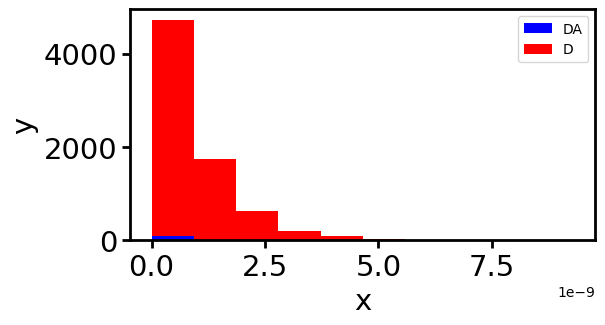

In [78]:
fi.universal_figure(type_='hist', data=[lifetimes_DA, lifetimes_D], stacked=True, color=['b', 'r'], label=['DA', 'D'], legend=True)

In [ ]:
ax = fi.universal_figure(nrows=len(DA_lifetimes), ncols=1, fig_width=4, fig_height=3*len(DA_lifetimes))
for i, (lifetimes, al_lifetime, D_lifetime) in enumerate(zip(DA_lifetimes, all_exp_lifetimes, D_lifetimes)):
    bins = np.linspace(min(al_lifetime), max(al_lifetime), 50)
    #fi.universal_figure(type_='hist', data=lifetimes, bins=bins, alpha=0.5, label='DA', color='r', axes=ax[i])
    fi.universal_figure(type_='hist', data=[D_lifetime, lifetimes], bins=bins, alpha=1, label=['D', 'DA'], color=['b', 'r'], axes=ax[i], 
    legend=True, tick_style_x='sci', yscale='log', stacked=True)
    ax[i, 0].figure.draw_without_rendering()
    exponent_x = ax[i, 0].xaxis.get_offset_text().get_text().split('e')[1]
    ax[i, 0].set_xlabel(rf'Lifetime [$10^{{{exponent_x}}}$s]')
    # exponent_y = ax[i, 0].yaxis.get_offset_text().get_text().split('e')[1]
    # ax[i, 0].set_ylabel(rf'count [x$10^{{{exponent_y}}}$]')
    ax[i, 0].legend(fontsize=14)
fig = mi.get_figure(ax)
fig.tight_layout()

## Continuous laser excitation

In [153]:
def get_DA_D_deexcitation_occurrences(simulation):
    """
    Returns the number of DA and D deexcitation events in a simulation.
    """
    D_deexcitation = [6, 7, 8, 9]
    DA_deexcitation = [10, 11, 24, 25]
    D_events = np.where(np.in1d(simulation.transition_series, D_deexcitation))[0]
    DA_events = np.where(np.in1d(simulation.transition_series, DA_deexcitation))[0]
    return D_events.size, DA_events.size

In [358]:
def get_specific_fl_lifetimes(simulation, emissions):
    """
    Returns fluorescence lifetimes of situations where (1) the fluorophore has no 
    energy transfer partner, (2) the fluorophore has an energy transfer partner.
    If a lifetime spans multiple transitions where the energy transfer partner becomes
    available or unavailable during the S1 lifetime, they are excluded, because they 
    falsify the assumption of a single exponential decay. This, on the other hand, also 
    falsifies it because there is a higher probability that longer lifetime samples are 
    affected by this.
    """
    DA_times = np.array([])
    D_times = np.array([])
    indices_times = np.where(np.in1d(simulation.time_series, emissions.event_time_points))[0]
    # indices of time points when emission occurs - to use on simulation series
    transitions = simulation.transition_series[indices_times-1]
    # the fluorescent emissions corresponding to indices_times
    i_DA_1 = np.where(transitions == 10)[0]
    i_DA_2 = np.where(transitions == 11)[0]
    i_D_1 = np.where(np.in1d(transitions, [7, 8]))[0]
    i_D_2 = np.where(np.in1d(transitions, [6, 9]))[0]
    # the indices of transitions when the transition was DA or D
    indices_DA = [i_DA_1, i_DA_2]
    indices_D = [i_D_1, i_D_2]

    for i, (state_series, indice_DA, indice_D) in enumerate(zip(simulation.state_series, indices_DA, indices_D)):
        state_indices_DA = indices_times[indice_DA]
        # the indices of time points when the transition was DA
        state_indices_D = indices_times[indice_D]
        # the indices of time points when the transition was D

        differences = np.diff(state_series)
        changes_at = np.where(differences != 0)[0]
        changed = changes_at + 1
        # the indices of state_series where the state changed

        states_DA = np.where(np.in1d(changed, state_indices_DA))[0]
        states_D = np.where(np.in1d(changed, state_indices_D))[0]
        # the indices of changed where state was DA or D

        starting_points_DA = changed[states_DA-1]
        starting_points_D = changed[states_D-1]
        # elements of changed that are starting points of DA or D transition

        if i == 0:
            other_state_series = simulation.state_series[1]
        else:
            other_state_series = simulation.state_series[0]
        
        uninterrupted_lifetimes_DA = np.where(other_state_series[starting_points_DA] == 3)[0]
        uninterrupted_lifetimes_D = np.where(other_state_series[starting_points_D] != 3)[0]

        relatives_DA = uninterrupted_lifetimes_DA.size / starting_points_DA.size
        relatives_D = uninterrupted_lifetimes_D.size / starting_points_D.size
        print(relatives_DA, relatives_D)

        starting_time_points_DA = simulation.time_series[starting_points_DA[uninterrupted_lifetimes_DA]]
        starting_time_points_D = simulation.time_series[starting_points_D[uninterrupted_lifetimes_D]]
        # the time points of the starting points of the uninterrupted lifetimes

        ending_points_DA = simulation.time_series[state_indices_DA[uninterrupted_lifetimes_DA]]
        ending_points_D = simulation.time_series[state_indices_D[uninterrupted_lifetimes_D]]
        # the time points of the ending points of the uninterrupted lifetimes

        times_DA = ending_points_DA - starting_time_points_DA
        times_D = ending_points_D - starting_time_points_D
        # the time differences, i.e., the lifetimes

        DA_times = np.concatenate([DA_times, times_DA])
        D_times = np.concatenate([D_times, times_D])

    return DA_times, D_times

### Example 1: low triplet yield

In [193]:
fluorophores = fl.construct_fluorophores(name="fluorophore", distance=10, count=2)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0, 1]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0, 1],
)
isc = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, 
    rate=1e8, 
    fluorophore_ids=[0, 1]
)
isc_2 = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS, 
    rate=1e4, 
    fluorophore_ids=[1, 0]
)
tfret = tr.Transition(
    transition_type=tr.TransitionType.S_T_ANNIHILATION,
    rate=5e9,
    fluorophore_ids=[(0, 1), (1, 0)],
)
transitions = {
    "fluorophore": [excitation, fluorescence, isc, isc_2],
    "D: fluorophore, A: fluorophore, dist: 10.0": [tfret],
}

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


In [224]:
transition_set.combined_state_transitions_df

,initial_state,final_state,abbreviation,transition_id,rate,photon
id,,,,,,
0,"(0, 0)","(0, 1)",EXC,0,1.000000e+09,False
1,"(0, 0)","(1, 0)",EXC,0,1.000000e+09,False
2,"(0, 1)","(1, 1)",EXC,0,1.000000e+09,False
3,"(0, 3)","(1, 3)",EXC,0,1.000000e+09,False
4,"(1, 0)","(1, 1)",EXC,0,1.000000e+09,False
5,"(3, 0)","(3, 1)",EXC,0,1.000000e+09,False
6,"(0, 1)","(0, 0)",FLU,1,1.000000e+09,True
7,"(1, 0)","(0, 0)",FLU,1,1.000000e+09,True
8,"(1, 1)","(0, 1)",FLU,1,1.000000e+09,True


In [228]:
emissions = em.Emissions()
durations = emissions.simulate(transition_set, frames=200,
    triplet_1=[12,14,17],
    triplet_2=[13,15,16],
    triplet_3=[18,19,23],
    triplet_4=[20, 21,22],)

1.00e-04
19928


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

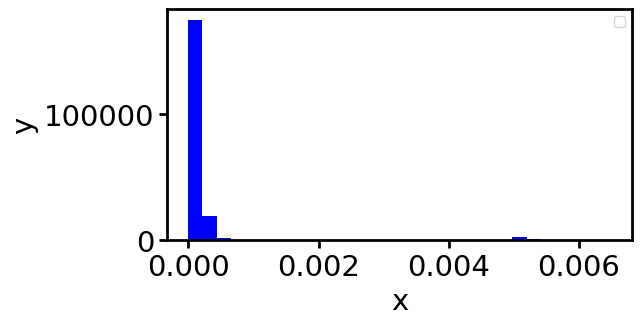

In [150]:
fi.universal_figure(type_='hist', data=durations, color='b', legend=True, bins=30)

In [220]:
current_state_lambda = 3.3
rng = np.random.default_rng()
random_numbers = rng.uniform(low=0, high=1, size=60000)
times = []
time = 0
for i in range(60000):
    transition_time = (
                    1
                    / current_state_lambda
                    * np.log(1 / random_numbers[i])
                )
    if transition_time > 0.2:
        time += 0.2
    else:
        times.append(time + transition_time)
        time = 0

In [198]:
1/3.3

0.30303030303030304

In [221]:
np.mean(times)

0.30177176384718934

In [194]:
simulation = si.Simulation(transition_set)
simulation.run(size=1e4, seed=3)
analysis = an.Analysis(simulation)
analysis.mean_lifetimes

{'fluorophore': array([1.00873602e-09, 1.69724143e-10, 1.04328493e-04])}

In [195]:
analysis.lifetime_distributions['fluorophore'][2].size

74

In [365]:
rates = np.logspace(6, 14, 10)
means = []
all_exp_lifetimes = []
other_means = []
DA_lifetimes = []
D_lifetimes = []
DA_D_event_ratio = []
DA_D_photon_ratio = []
for rate in rates:
    tfret = tr.Transition(
    transition_type=tr.TransitionType.S_T_ANNIHILATION,
    rate=rate,
    fluorophore_ids=[(0, 1), (1, 0)],
    )
    transitions = {
        "fluorophore": [excitation, fluorescence, isc, isc_2],
        "D: fluorophore, A: fluorophore, dist: 10.0": [tfret],
    }
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(seed=4, end_time=1e-2)
    analysis = an.Analysis(simulation)
    fluorescence_lifetimes = analysis.get_fluorescence_lifetimes()
    exp_fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes('fluorophore')
    mean = np.mean(fluorescence_lifetimes)
    means.append(mean)
    other_mean = np.mean(exp_fluorescence_lifetimes)
    other_means.append(other_mean)
    all_exp_lifetimes.append(exp_fluorescence_lifetimes)
    emissions = em.Emissions('5ms', seed=1)
    emissions.extract(simulation)
    a,b = get_specific_fl_lifetimes(simulation, emissions)
    DA_lifetimes.append(a)
    D_lifetimes.append(b)
    DA_D_photon_ratio.append(a.size/b.size)
    D_events, DA_events = get_DA_D_deexcitation_occurrences(simulation)
    DA_D_event_ratio.append(DA_events/D_events)

0.9999823650263202 0.9993409490333919
0.9999835141283919 0.999782466826191
0.999989225995518 0.9993755853886981
0.9999778572456628 0.9990850869167429
0.9999895232008716 0.9993755853886981
0.9999777146359129 0.9990850869167429
0.9999898749557029 1.0
0.9999896081222917 0.9995089614534741


KeyboardInterrupt: 

In [305]:
for DA, D in zip(DA_lifetimes, D_lifetimes):
    print(DA.size + D.size)
    print(DA.mean())
    print(D.mean())

135650
9.869433757099298e-10
9.949102817171815e-10
132513
9.794126460423432e-10
9.968923348628758e-10
136141
9.356356808404913e-10
9.936725716404526e-10
124340
6.81810536711194e-10
9.898789919787276e-10
96285
2.1610782636484767e-10
9.900437192361815e-10
80700
3.4419057889208955e-11
9.900153045064676e-10
76833
4.5502456131468446e-12
9.908301623349527e-10
77397
5.817615601627862e-13
9.910410013679365e-10
77465
6.056037003576056e-14
9.905646944624173e-10
77451
5.9200329823501834e-15
9.905646944624173e-10


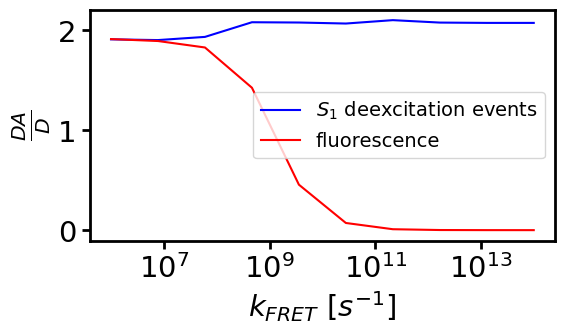

In [301]:
ax = fi.universal_figure(type_='line', data=[rates, DA_D_event_ratio], label=r'$S_1$ deexcitation events')
fi.universal_figure(type_='line', data=[rates, DA_D_photon_ratio], label='fluorescence', axes=ax,
                    xscale='log', xlabel=r'$k_{FRET}\ [s^{-1}]$', ylabel=r'$\frac{DA}{D}$', color='r', legend=True,
                    )
ax[0, 0].legend(fontsize=14)
fig = mi.get_figure(ax)
fig.savefig('DA_D_ratios_ex1.svg')

WARNING for line:         ax.set_yscale(yscale)
 Data has no positive values, and therefore cannot be log-scaled. 


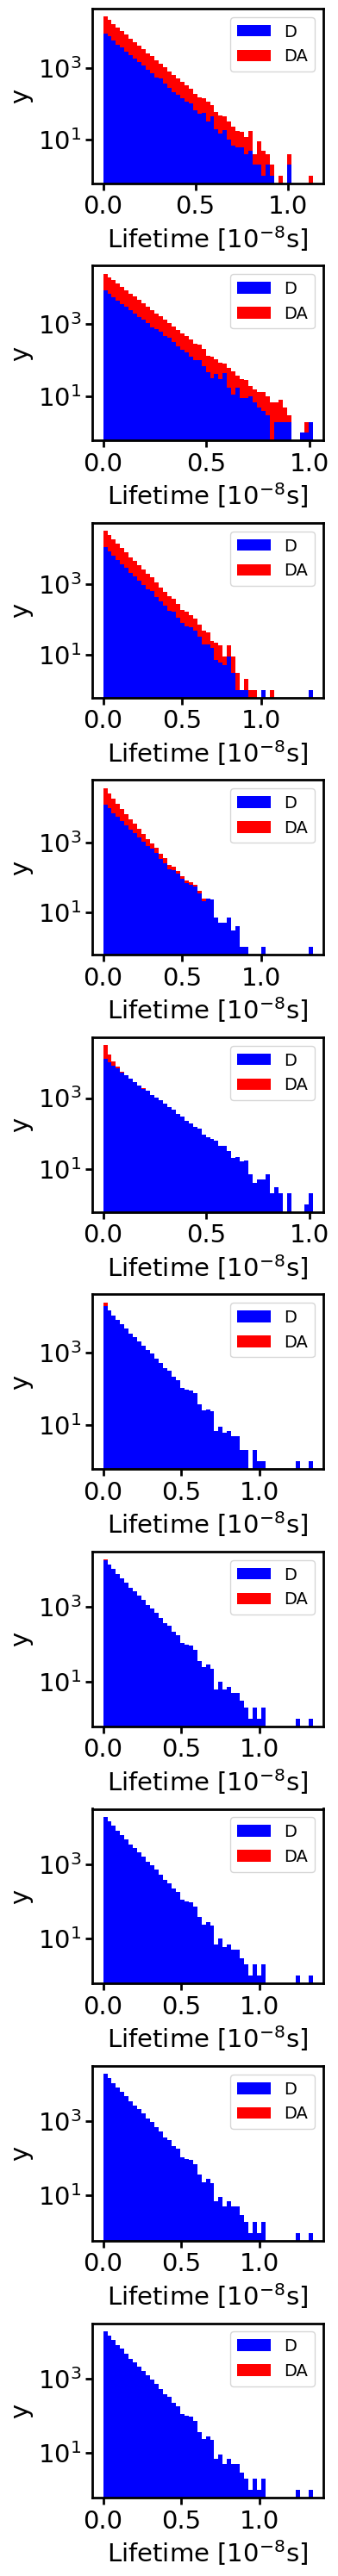

In [302]:
ax = fi.universal_figure(nrows=len(DA_lifetimes), ncols=1, fig_width=4, fig_height=3*len(DA_lifetimes))
for i, (lifetimes, al_lifetime, D_lifetime) in enumerate(zip(DA_lifetimes, all_exp_lifetimes, D_lifetimes)):
    bins = np.linspace(min(al_lifetime), max(al_lifetime), 50)
    #fi.universal_figure(type_='hist', data=lifetimes, bins=bins, alpha=0.5, label='DA', color='r', axes=ax[i])
    fi.universal_figure(type_='hist', data=[D_lifetime, lifetimes], bins=bins, alpha=1, label=['D', 'DA'], color=['b', 'r'], axes=ax[i], 
    legend=True, tick_style_x='sci', yscale='log', stacked=True)
    ax[i, 0].figure.draw_without_rendering()
    exponent_x = ax[i, 0].xaxis.get_offset_text().get_text().split('e')[1]
    ax[i, 0].set_xlabel(rf'Lifetime [$10^{{{exponent_x}}}$s]')
    # exponent_y = ax[i, 0].yaxis.get_offset_text().get_text().split('e')[1]
    # ax[i, 0].set_ylabel(rf'count [x$10^{{{exponent_y}}}$]')
    ax[i, 0].legend(fontsize=14)
fig = mi.get_figure(ax)
fig.tight_layout()
fig.savefig('DA_D_lifetimes_ex1.svg')

In [199]:
def mixture_pdf(x, lambda1, lambda2, mixing_coefficient):
    pdf1 = lambda1 * np.exp(-lambda1 * x)
    pdf2 = lambda2 * np.exp(-lambda2 * x)
    return mixing_coefficient * pdf1 + (1 - mixing_coefficient) * pdf2

WARNING for line:         ax.set_yscale(yscale)
 Data has no positive values, and therefore cannot be log-scaled. 


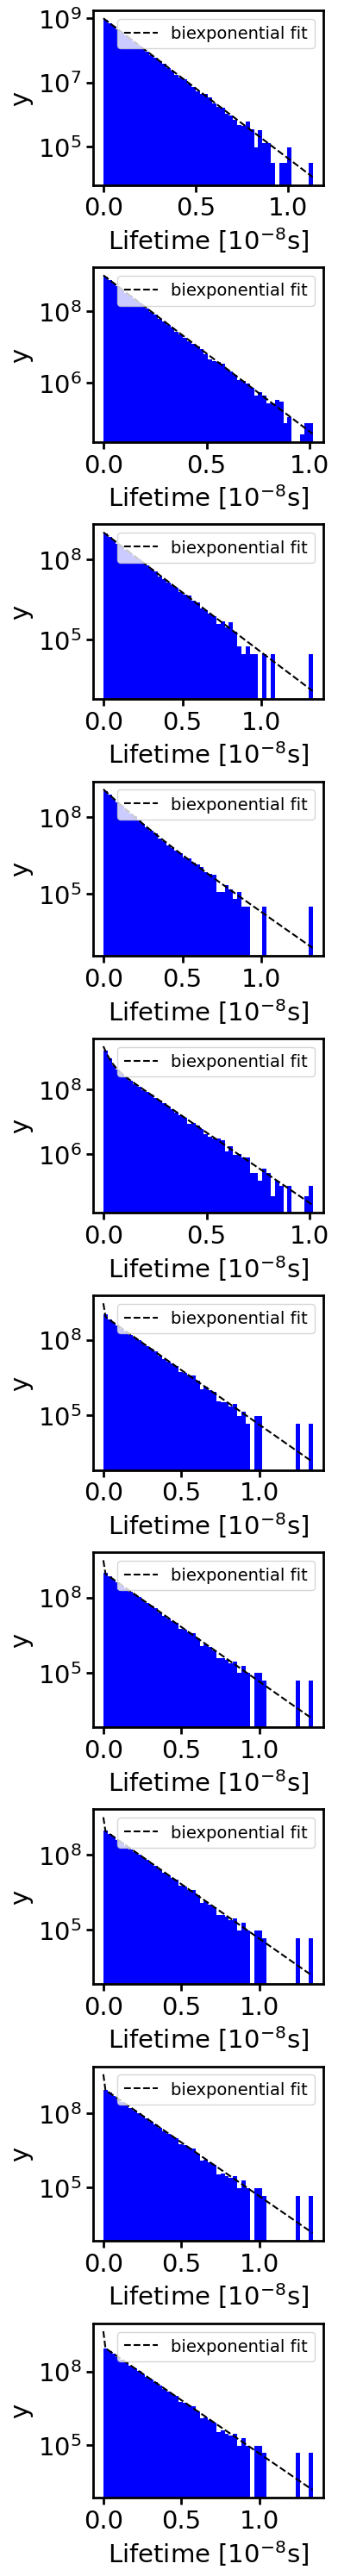

In [306]:
ax = fi.universal_figure(nrows=len(DA_lifetimes), ncols=1, fig_width=4, fig_height=3*len(DA_lifetimes))
for i, (lifetimes, al_lifetime, D_lifetime, rate) in enumerate(zip(DA_lifetimes, all_exp_lifetimes, D_lifetimes, rates)):
    #fi.universal_figure(type_='hist', data=lifetimes, bins=bins, alpha=0.5, label='DA', color='r', axes=ax[i])
    dat = np.concatenate([D_lifetime, lifetimes])
    fi.universal_figure(type_='hist', data=dat, bins=50, alpha=1, axes=ax[i], 
    tick_style_x='sci', yscale='log', density=True)
    x = np.linspace(min(dat), max(dat), 100)
    perfect_params = [rate + 1e9 + 1e6, 1e9 + 1e6, lifetimes.size/dat.size]
    y_fit_perfect = mixture_pdf(x, *perfect_params)
    ax[i, 0].plot(x, y_fit_perfect, color='k', linestyle='--', label='biexponential fit')
    ax[i, 0].figure.draw_without_rendering()
    exponent_x = ax[i, 0].xaxis.get_offset_text().get_text().split('e')[1]
    ax[i, 0].set_xlabel(rf'Lifetime [$10^{{{exponent_x}}}$s]')
    # exponent_y = ax[i, 0].yaxis.get_offset_text().get_text().split('e')[1]
    # ax[i, 0].set_ylabel(rf'count [x$10^{{{exponent_y}}}$]')
    ax[i, 0].legend(fontsize=14)
fig = mi.get_figure(ax)
fig.tight_layout()

#### fit the data using mono or biexponentials and compare their fit

In [324]:
import scipy.stats as stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def exponential(x, lambd):
    return lambd * np.exp(-lambd * x)

def biexponential(x, lambd1, lambd2, weight):
    return weight * lambd1 * np.exp(-lambd1 * x) + (1 - weight) * lambd2 * np.exp(-lambd2 * x)

# Calculate the AIC for each model
def calculate_aic(y, y_fit, num_params):
    residuals = y - y_fit
    sse = np.sum(residuals**2)
    # print(f'{sse:.2e}')
    aic = 2 * num_params + len(y) * np.log(sse / len(y))
    return aic

for i, (lifetimes, D_lifetime, rate) in enumerate(zip(DA_lifetimes, D_lifetimes, rates)):
    data = np.concatenate([lifetimes, D_lifetime])
    bin_num = int(np.sqrt(data.size))*2
    y, bin_edges = np.histogram(data, bins=bin_num, density=True)
    # print(y)
    x = (bin_edges[1:] + bin_edges[:-1]) / 2
    params_exp, _ = curve_fit(exponential, x, y, p0=(1.0/np.mean(data)))
    params_biexp, _ = curve_fit(biexponential, x, y, p0=(rate + 1e9 + 1e6, 1e9 + 1e6, lifetimes.size/data.size))
    y_fit_exp = exponential(x, *params_exp)
    y_fit_biexp = biexponential(x, *params_biexp)
    print(params_biexp)
    perfect_params = [rate + 1e9 + 1e6, 1e9 + 1e6, lifetimes.size/data.size]
    y_fit_perfect = biexponential(x, *perfect_params)
    print(perfect_params)
    # print(y_fit_perfect)
    aic_exp = calculate_aic(y, y_fit_exp, len(params_exp))
    aic_biexp = calculate_aic(y, y_fit_biexp, len(params_biexp))
    aic_perfect = calculate_aic(y, y_fit_perfect, 3)
    print(f"AIC for exponential fit: {aic_exp}")
    print(f"AIC for biexponential fit: {aic_biexp}")
    print(f"AIC for perfect fit: {aic_perfect}")
    print('NEXT')

[1.01308729e+09 1.01308606e+09 2.25102640e+00]
[1002000000.0, 1001000000.0, 0.6565057132325839]
AIC for exponential fit: 22902.677448657912
AIC for biexponential fit: 22906.67745093104
AIC for perfect fit: 22968.323499622133
NEXT
[1.78509897e+09 1.00182216e+09 2.59375764e-02]
[1008742636.8268113, 1001000000.0, 0.6542075117158317]
AIC for exponential fit: 22895.425998677558
AIC for biexponential fit: 22892.186349731863
AIC for perfect fit: 22958.21818440664
NEXT
[1.55174849e+09 1.02538242e+09 5.40843503e-02]
[1060948425.0318941, 1001000000.0, 0.646307871985662]
AIC for exponential fit: 22721.002031242875
AIC for biexponential fit: 22714.674004866134
AIC for perfect fit: 22784.57493919963
NEXT
[1.44589298e+09 9.41602562e+08 6.78489591e-01]
[1465158883.3612773, 1001000000.0, 0.587566350329741]
AIC for exponential fit: 21951.303445343627
AIC for biexponential fit: 21812.933945074452
AIC for perfect fit: 21846.57038685286
NEXT
[4.54041593e+09 9.98616759e+08 3.23763228e-01]
[4594813663.80462

WARNING for line:     return weight * lambd1 * np.exp(-lambd1 * x) + (1 - weight) * lambd2 * np.exp(-lambd2 * x)
 overflow encountered in exp 
WARNING for line:     params_biexp, _ = curve_fit(biexponential, x, y, p0=(rate + 1e9 + 1e6, 1e9 + 1e6, lifetimes.size/data.size))
 Covariance of the parameters could not be estimated 


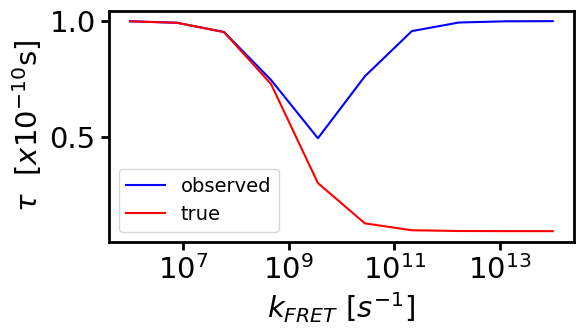

In [160]:
ax = fi.universal_figure(data=[rates, other_means], label='observed')
fi.universal_figure(data=[rates, means], axes=ax, xscale='log', xlabel=r'$k_{FRET}\ [s^{-1}]$',
                    ylabel=r'$\tau\ \ [x10^{-10}$s]', tick_style_y='sci', color='red',
                    label='true', legend=True)
ax[0, 0].legend(fontsize=14)
fig = mi.get_figure(ax)
fig.savefig('mean_lifetime_vs_fret_rate_ex1.svg')

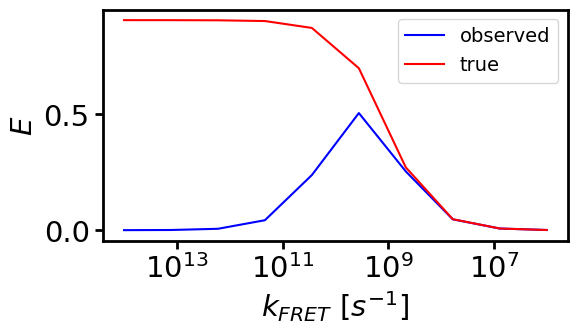

In [162]:
exp_efficiency = 1 - np.array(other_means) / 1e-9
efficiency = 1 - np.array(means) / 1e-9
ax = fi.universal_figure(data=[rates, exp_efficiency], label='observed')
fi.universal_figure(data=[rates, efficiency], axes=ax, xscale='log',
                    xlabel=r'$k_{FRET}\ [s^{-1}]$', label='true', legend=True,
                    ylabel=r'$E$', color='red',
                    )
ax[0,0].invert_xaxis()
ax[0, 0].legend(fontsize=14)
fig = mi.get_figure(ax)
fig.savefig('efficiency_vs_fret_rate_ex1.svg')

#### one fluorophore

In [150]:
fluorophores = fl.construct_fluorophores(name="fluorophore", distance=10, count=1)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0],
)
isc = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, 
    rate=1e6, 
    fluorophore_ids=[0]
)
isc_2 = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS, 
    rate=1e5, 
    fluorophore_ids=[0]
)
transitions = {
    "fluorophore": [excitation, fluorescence, isc, isc_2],
}

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


In [151]:
simulation = si.Simulation(transition_set)
simulation.run(seed=4, end_time=1e-2)
analysis = an.Analysis(simulation)
emissions = em.Emissions('5ms', seed=1)
emissions.extract(simulation)
print(emissions.event_time_points.size)

834332


### Example 2: High triplet yield

In [128]:
fluorophores = fl.construct_fluorophores(name="fluorophore", distance=10, count=2)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0, 1]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0, 1],
)
isc = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, 
    rate=1e8, 
    fluorophore_ids=[0, 1]
)
isc_2 = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS, 
    rate=1e5, 
    fluorophore_ids=[1, 0]
)
tfret = tr.Transition(
    transition_type=tr.TransitionType.S_T_ANNIHILATION,
    rate=5e9,
    fluorophore_ids=[(0, 1), (1, 0)],
)
transitions = {
    "fluorophore": [excitation, fluorescence, isc, isc_2],
    "D: fluorophore, A: fluorophore, dist: 10.0": [tfret],
}

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


In [136]:
rates = np.logspace(6, 14, 10)
means = []
all_exp_lifetimes = []
other_means = []
DA_lifetimes = []
D_lifetimes = []
DA_D_event_ratio = []
DA_D_photon_ratio = []
for rate in rates:
    tfret = tr.Transition(
    transition_type=tr.TransitionType.S_T_ANNIHILATION,
    rate=rate,
    fluorophore_ids=[(0, 1), (1, 0)],
    )
    transitions = {
        "fluorophore": [excitation, fluorescence, isc, isc_2],
        "D: fluorophore, A: fluorophore, dist: 10.0": [tfret],
    }
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(seed=4, end_time=1e-1)
    analysis = an.Analysis(simulation)
    fluorescence_lifetimes = analysis.get_fluorescence_lifetimes()
    exp_fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes('fluorophore')
    mean = np.mean(fluorescence_lifetimes)
    means.append(mean)
    other_mean = np.mean(exp_fluorescence_lifetimes)
    other_means.append(other_mean)
    all_exp_lifetimes.append(exp_fluorescence_lifetimes)
    emissions = em.Emissions('5ms', seed=1)
    emissions.extract(simulation)
    a,b = get_specific_fl_lifetimes(simulation, emissions)
    DA_lifetimes.append(a)
    D_lifetimes.append(b)
    DA_D_photon_ratio.append(a.size/b.size)
    D_events, DA_events = get_DA_D_deexcitation_occurrences(simulation)
    DA_D_event_ratio.append(DA_events/D_events)

0.01385727011779636
0.012948207171319837
0.013994682020836535
0.0129696510166184
0.012433558173512438
0.010012615896030752
0.011882364590547922
0.011009688525902561
0.004040648928210544
0.005240650679184
0.0063801280278994454
0.007428632070457297
0.0014159292035458293
0.0
0.0
0.004333318888939175
0.0
0.0
0.0
0.0


In [145]:
for DA, D in zip(DA_lifetimes, D_lifetimes):
    print(DA.size + D.size)

201671
200513
196634
201233
195031
191362
156829
86824
59320
54512


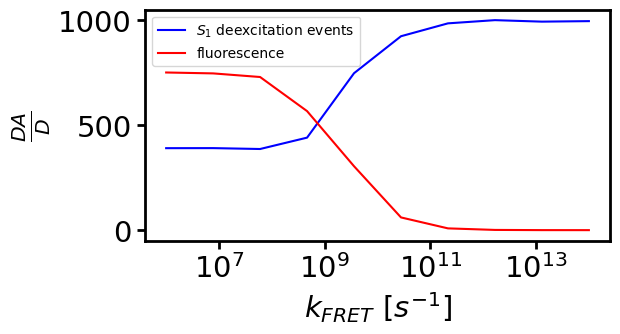

In [137]:
ax = fi.universal_figure(type_='line', data=[rates, DA_D_event_ratio], label=r'$S_1$ deexcitation events')
fi.universal_figure(type_='line', data=[rates, DA_D_photon_ratio], label='fluorescence', axes=ax,
                    xscale='log', xlabel=r'$k_{FRET}\ [s^{-1}]$', ylabel=r'$\frac{DA}{D}$', color='r', legend=True)
fig = mi.get_figure(ax)
fig.savefig('DA_D_ratios_ex2.svg')

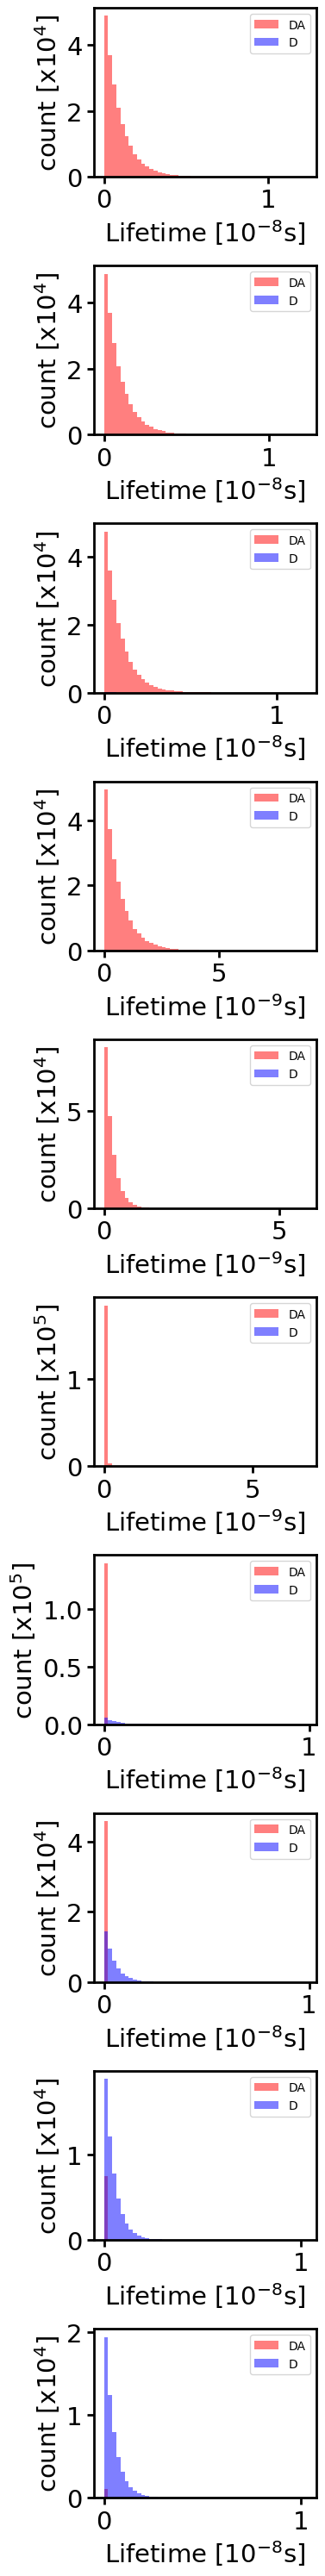

In [139]:
ax = fi.universal_figure(nrows=len(DA_lifetimes), ncols=1, fig_width=4, fig_height=3*len(DA_lifetimes))
for i, (lifetimes, al_lifetime, D_lifetime) in enumerate(zip(DA_lifetimes, all_exp_lifetimes, D_lifetimes)):
    bins = np.linspace(min(al_lifetime), max(al_lifetime), 50)
    fi.universal_figure(type_='hist', data=lifetimes, bins=bins, alpha=0.5, label='DA', color='r', axes=ax[i])
    fi.universal_figure(type_='hist', data=D_lifetime, bins=bins, alpha=0.5, label='D', color='b', axes=ax[i], 
    legend=True, tick_style_y='sci', tick_style_x='sci')
    ax[i, 0].figure.draw_without_rendering()
    exponent_x = ax[i, 0].xaxis.get_offset_text().get_text().split('e')[1]
    ax[i, 0].set_xlabel(rf'Lifetime [$10^{{{exponent_x}}}$s]')
    exponent_y = ax[i, 0].yaxis.get_offset_text().get_text().split('e')[1]
    ax[i, 0].set_ylabel(rf'count [x$10^{{{exponent_y}}}$]')
fig = mi.get_figure(ax)
fig.tight_layout()
fig.savefig('DA_D_lifetimes_ex2.svg')

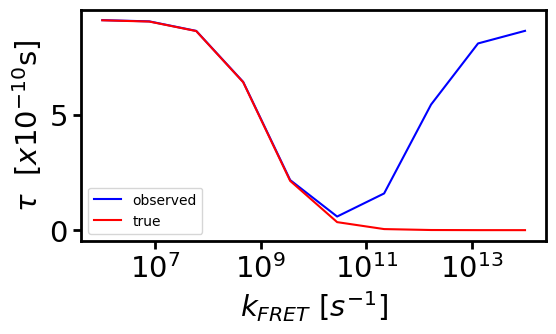

In [140]:
ax = fi.universal_figure(data=[rates, other_means], label='observed')
fi.universal_figure(data=[rates, means], axes=ax, xscale='log', xlabel=r'$k_{FRET}\ [s^{-1}]$',
                    ylabel=r'$\tau\ \ [x10^{-10}$s]', tick_style_y='sci', color='red',
                    label='true', legend=True)
fig = mi.get_figure(ax)
fig.savefig('mean_lifetime_vs_fret_rate_ex2.svg')

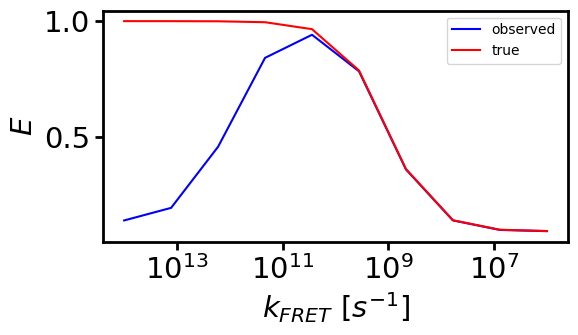

In [141]:
exp_efficiency = 1 - np.array(other_means) / 1e-9
efficiency = 1 - np.array(means) / 1e-9
ax = fi.universal_figure(data=[rates, exp_efficiency], label='observed')
fi.universal_figure(data=[rates, efficiency], axes=ax, xscale='log',
                    xlabel=r'$k_{FRET}\ [s^{-1}]$', label='true', legend=True,
                    ylabel=r'$E$', color='red',
                    )
ax[0,0].invert_xaxis()
fig = mi.get_figure(ax)
fig.savefig('efficiency_vs_fret_rate_ex2.svg')

#### One fluorophore

In [142]:
fluorophores = fl.construct_fluorophores(name="fluorophore", distance=10, count=1)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0],
)
isc = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, 
    rate=1e8, 
    fluorophore_ids=[0]
)
isc_2 = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS, 
    rate=1e5, 
    fluorophore_ids=[0]
)
transitions = {
    "fluorophore": [excitation, fluorescence, isc, isc_2],
}

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


In [144]:
simulation = si.Simulation(transition_set)
simulation.run(seed=4, end_time=1e-1)
analysis = an.Analysis(simulation)
emissions = em.Emissions('5ms', seed=1)
emissions.extract(simulation)
print(emissions.event_time_points.size)

100361


### Example 3: Different fluorophores, standard FRET

In [86]:
fluorophore_1 = fl.Fluorophore(name="fluorophore_1", position=(0, 0))
fluorophore_2 = fl.Fluorophore(name="fluorophore_2", position=(0, 10))
fluorophores = [fluorophore_1, fluorophore_2]
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0],
)
fluorescence_2 = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[1],
)
isc = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, 
    rate=1e6, 
    fluorophore_ids=[0]
)
isc_2 = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS, 
    rate=1e5, 
    fluorophore_ids=[0]
)
fret = tr.Transition(
    transition_type=tr.TransitionType.FRET,
    rate=5e9,
    fluorophore_ids=[(0, 1)],
)
transitions = {
    "fluorophore_1": [excitation, fluorescence, isc, isc_2],
    "fluorophore_2": [fluorescence_2],
    "D: fluorophore_1, A: fluorophore_2, dist: 10.0": [fret],
}

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

WARNING for line:             warnings.warn(
 Fluorophore fluorophore_1 not known. Parameters have to be defined manually. 
WARNING for line:             warnings.warn(
 Fluorophore fluorophore_2 not known. Parameters have to be defined manually. 


In [ ]:
rates = np.logspace(6, 14, 10)
means = []
all_exp_lifetimes = []
other_means = []
DA_lifetimes = []
D_lifetimes = []
DA_D_event_ratio = []
DA_D_photon_ratio = []
for rate in rates:
    tfret = tr.Transition(
    transition_type=tr.TransitionType.S_T_ANNIHILATION,
    rate=rate,
    fluorophore_ids=[(0, 1), (1, 0)],
    )
    transitions = {
        "fluorophore": [excitation, fluorescence, isc, isc_2],
        "D: fluorophore, A: fluorophore, dist: 10.0": [tfret],
    }
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(seed=4, end_time=1e-1)
    analysis = an.Analysis(simulation)
    fluorescence_lifetimes = analysis.get_fluorescence_lifetimes()
    exp_fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes('fluorophore')
    mean = np.mean(fluorescence_lifetimes)
    means.append(mean)
    other_mean = np.mean(exp_fluorescence_lifetimes)
    other_means.append(other_mean)
    all_exp_lifetimes.append(exp_fluorescence_lifetimes)
    emissions = em.Emissions('5ms', seed=1)
    emissions.extract(simulation)
    a,b = get_specific_fl_lifetimes(simulation, emissions)
    DA_lifetimes.append(a)
    D_lifetimes.append(b)
    DA_D_photon_ratio.append(a.size/b.size)
    D_events, DA_events = get_DA_D_deexcitation_occurrences(simulation)
    DA_D_event_ratio.append(DA_events/D_events)